In [82]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

TBIID_filename = "TBIID.csv"
TBIIDMulti_filename = "TBIIDMulti.csv"

TBIID_filepath = os.path.join('..', 'Database', 'TBIMSPublic.2024-11-01', 'Data',TBIID_filename)
TBIIDMulti_filepath = os.path.join('..', 'Database', 'TBIMSPublic.2024-11-01', 'Data',TBIIDMulti_filename)

form_2_path = os.path.join('..','Database', 'processed','form_2_cleaned_v2.csv')


#read in csv as dataframe
tbiid = pd.read_csv(TBIID_filepath)
tbiidMulti = pd.read_csv(TBIIDMulti_filepath)
df_form_2 = pd.read_csv(form_2_path)

df_tbiid = pd.concat([tbiid, tbiidMulti], axis=0, ignore_index=True)

df_tbiid = df_tbiid.groupby('Mod1Id').agg(lambda x: '; '.join(map(str, x.unique()))).reset_index()

#select followup period
df_form_2_followup = df_form_2[df_form_2['FollowUpPeriodGroup'] == 10].copy()

#prepare labels
df_form_2_followup['drs_outcome'] = pd.cut(
    df_form_2_followup['CombinedDRSF'], 
    bins=[0,21,30], 
    right=True, 
    labels=[0,1]
)

df_form_2_labels = df_form_2_followup[['Mod1Id', 'drs_outcome']]


#remove NA
df_form_2_labels = df_form_2_labels.dropna(subset=['Mod1Id', 'drs_outcome'])

#merge labels on training data
data = pd.merge(
    df_tbiid,
    df_form_2_labels,
    on='Mod1Id',
    how='inner'
                )


#check merge, how many rows were dropped?
print(df_tbiid.shape)
print(data.shape) 

data = data.dropna()

data['drs_outcome'].value_counts()


C:\Users\benol\AppData\Local\Temp\ipykernel_41920\4237016235.py:19: DtypeWarning: Columns (62,63,248,251,252) have mixed types. Specify dtype option on import or set low_memory=False.
  df_form_2 = pd.read_csv(form_2_path)


(6546, 13)
(1902, 14)


drs_outcome
0    1748
1     154
Name: count, dtype: int64

In [83]:
import html
import contractions
import nltk
from nltk.corpus import stopwords

#remove contractions
data['tbiCause'] = data['tbiCause'].apply(lambda text: contractions.fix(text)) 

#Remove Hyperlinks, Digits, and Punctuation
data['tbiCause'] = data['tbiCause'].apply(lambda text: re.sub(r"http\S+", '', text)) 
data['tbiCause'] = data['tbiCause'].apply(lambda text: re.sub(r'\d', '', text))

#remove escaping characters
data['tbiCause'] = html.unescape(data['tbiCause'])

#remove punctuation
data['tbiCause'] = data['tbiCause'].str.replace(r'[^\w\s]','')
data['tbiCause'] = data['tbiCause'].str.replace("_", " ")

nltk.download('popular')


#remove stopwords
stop = set(stopwords.words('english'))

data['tbiCause'] = data['tbiCause'].apply(lambda x: ' '.join([word.lower() for word in x.split() if word.lower() not in (stop)]))


data.head()

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\benol\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     C:\Users\benol\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     C:\Users\benol\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     C:\Users\benol\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     C:\Users\benol\AppData\Roaming\nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]   

,Mod1Id,Mod2TBIId,Mod2Id,tbiCause,tbiLOC,tbiDazed,tbiAge,Mod2TBIMultiId,tbiCauseMulti,tbiLOCMulti,tbiSevereMulti,tbiAgeBegan,tbiAgeEnd,drs_outcome
0,12,1382.0; 5912.0; 7465.0; 7677.0; 7810.0; 7811.0,11512,mva - neck injury; fall - hit head; fight,2.0; 1.0; 3.0,88.0; 1.0,15.0; nan; 26.0; 22.0,nan,nan,nan,nan,nan,nan,0
1,20,1397.0; 6787.0,44750,smashed head head bull; hit head child- six st...,2.0; 1.0,1.0; 0.0,22.0; 10.0,nan,nan,nan,nan,nan,nan,1
2,28,5964.0,35848,fell,2.0,1.0,92.0,nan,nan,nan,nan,nan,nan,1
3,29,986.0; 4749.0,5147; 49498,nan; assault,nan; 3.0,nan; 88.0,nan; 20.0,nan,nan,nan,nan,nan,nan,0
4,38,2160.0; 6848.0,52195,fall,1.0,0.0,36.0,nan,nan,nan,nan,nan,nan,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import numpy as np

corpus = np.array(data.tbiCause)
labels = np.array(data.drs_outcome)
#declare count_vect and tfidf_transformer
count_vect = CountVectorizer(binary=False, ngram_range=(1,1))
tfidf_transformer = TfidfTransformer()

#split
X_train, X_test, y_train, y_test  = train_test_split(corpus, labels, test_size=0.25, random_state=42)

#tokenize
X_train_counts = count_vect.fit_transform(X_train)
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

#examine training features
print(X_train_tfidf.shape)

#examine features
X_test_counts = count_vect.transform(X_test)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

print(X_test_tfidf.shape)

(1426, 831)
(476, 831)


c:\Users\benol\miniconda3\envs\ps\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\benol\miniconda3\envs\ps\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\benol\miniconda3\envs\ps\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\benol\minico


Naive Bayes
Precision (class 1): 0.000, Recall (class 1): 0.000
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       446
           1       0.00      0.00      0.00        30

    accuracy                           0.94       476
   macro avg       0.47      0.50      0.48       476
weighted avg       0.88      0.94      0.91       476


Logistic Regression
Precision (class 1): 0.000, Recall (class 1): 0.000
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       446
           1       0.00      0.00      0.00        30

    accuracy                           0.94       476
   macro avg       0.47      0.50      0.48       476
weighted avg       0.88      0.94      0.91       476


Linear SVM
Precision (class 1): 1.000, Recall (class 1): 0.033
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       446
           1       1.00      0.03  

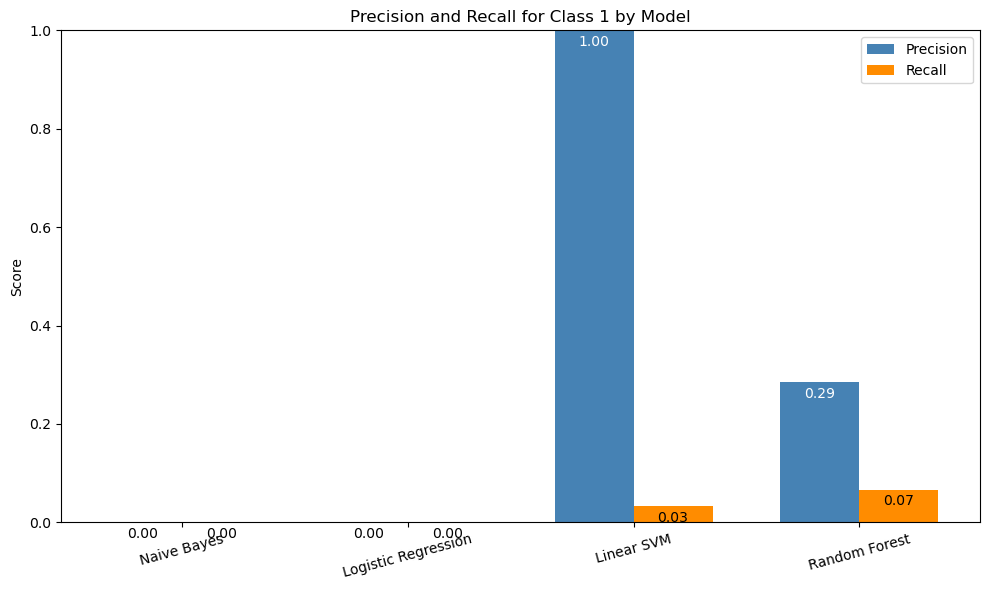

In [92]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt




#Define classifiers in a dictionary
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier()
}

# Store scores
model_names = []
precision_class_1_scores = []
recall_class_1_scores = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    precision = precision_score(y_test, predictions, pos_label=1)
    recall = recall_score(y_test, predictions, pos_label=1)

    model_names.append(name)
    precision_class_1_scores.append(precision)
    recall_class_1_scores.append(recall)

    print(f"\n{name}")
    print(f"Precision (class 1): {precision:.3f}, Recall (class 1): {recall:.3f}")
    print(classification_report(y_test, predictions))

# 📊 Plot grouped bar chart
x = np.arange(len(model_names))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, precision_class_1_scores, width, label='Precision', color='steelblue')
bars2 = ax.bar(x + width/2, recall_class_1_scores, width, label='Recall', color='darkorange')

# Add text labels inside bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height - 0.01,
            f'{height:.2f}',
            ha='center',
            va='top',
            color='white' if height > 0.15 else 'black',
            fontsize=10
        )

# Formatting
ax.set_ylabel('Score')
ax.set_title('Precision and Recall for Class 1 by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()